### Import Modules


In [1]:
# Standard Library
import random
from datetime import datetime, timezone
from pathlib import Path

# Packages
import mlflow, numpy, pandas, shap
from matplotlib import pyplot
from sklearn.model_selection import train_test_split

C:\Users\Reaven\Projects\Personal\Practice\fraud-detection-platform\notebooks\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Constants & Config


In [2]:
# Paths
ROOT_DIR = Path("../").resolve()

# Data
TEST_SIZE = 0.2
START_DATE = datetime(2013, 9, 1, tzinfo=timezone.utc)
SEED_PATH = (
    ROOT_DIR
    / "database"
    / "seed"
    / "transaction_inferences"
    / "creditcard_transactions.csv.gz"
)

# Reproducibility
RANDOM_STATE = 42
RNG = numpy.random.default_rng(RANDOM_STATE)
random.seed(RANDOM_STATE)
numpy.random.seed(RANDOM_STATE)

# MLflow
MLFLOW_DIR = Path("./mlflow").resolve()
MLFLOW_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(f"sqlite:///{(MLFLOW_DIR / 'mlflow.db').as_posix()}")

### Load Data


In [3]:
seed_df = pandas.read_csv(
    SEED_PATH,
    compression="gzip",
    dtype={
        "Time": "float64",
        **{f"V{i}": "float64" for i in range(1, 29)},
        "Amount": "float64",
        "Class": "int8",
    },
)

# Convert seconds offset to epoch seconds (int64), same as the training dataset
df = pandas.DataFrame({
    "is_fraud": seed_df["Class"].astype("int64"),
    "transaction_timestamp": (
        START_DATE.timestamp() + seed_df["Time"]
    ).astype("int64"),
    "amount": seed_df["Amount"],
    **{f"v{i}": seed_df[f"V{i}"] for i in range(1, 29)},
})

x = df.drop("is_fraud", axis=1)
y = df["is_fraud"]

# Same split as notebook 02
train_x, test_x, train_y, test_y = train_test_split(
    x, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

test_x_np = test_x.to_numpy(dtype=numpy.float64)
test_y_np = test_y.to_numpy(dtype=numpy.int64)
feature_names = list(test_x.columns)

print(f"Data shape: {df.shape}")
print(f"Test shape: {test_x.shape}")
print(feature_names)

Data shape: (284807, 31)
Test shape: (56962, 30)
['transaction_timestamp', 'amount', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'v7', 'v8', 'v9', 'v10', 'v11', 'v12', 'v13', 'v14', 'v15', 'v16', 'v17', 'v18', 'v19', 'v20', 'v21', 'v22', 'v23', 'v24', 'v25', 'v26', 'v27', 'v28']


### Load Model


In [4]:
xgb = mlflow.sklearn.load_model(model_uri="models:/XGBoost/latest")

print(xgb.named_steps.keys())
xgb_robust_scaler = xgb.named_steps["robust_scaler"]
xgb_model = xgb.named_steps["xgb"]
xgb_model

dict_keys(['robust_scaler', 'smote', 'xgb'])


,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.7524934863193213
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",'cuda'
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### Load Model Interpreter


In [5]:
explainer = shap.TreeExplainer(xgb_model)
test_x_scaled_np = xgb_robust_scaler.transform(test_x_np)
shap_values = explainer.shap_values(test_x_scaled_np)

### Global Importance


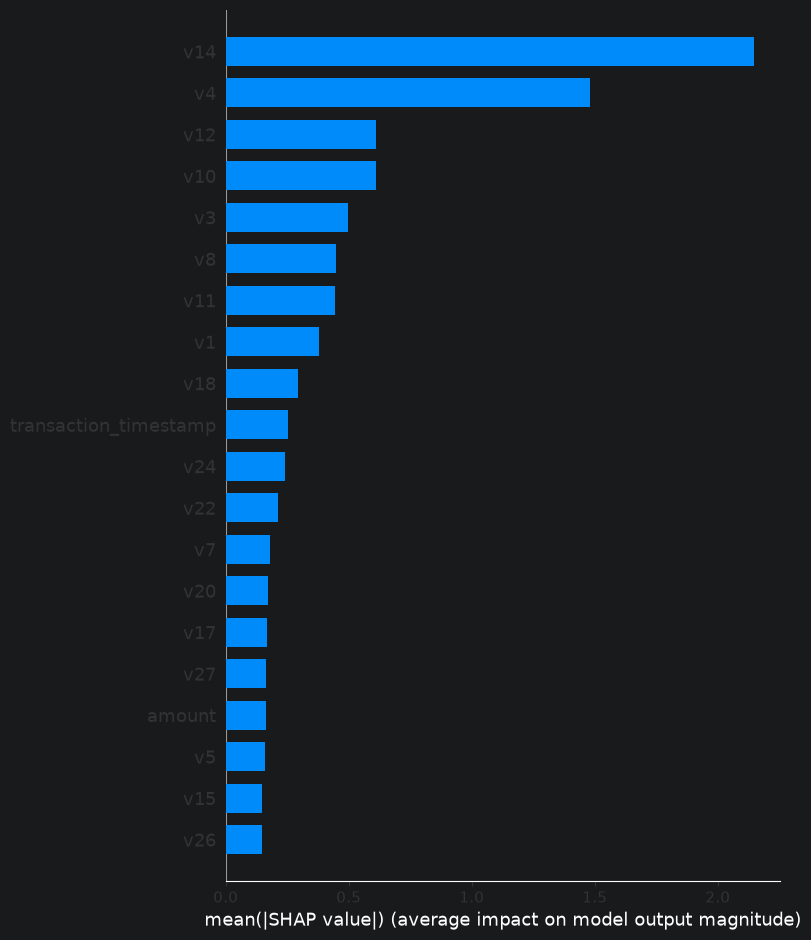

In [6]:
shap.summary_plot(
    shap_values,
    test_x_np,
    plot_type="bar",
    feature_names=feature_names,
    rng=RNG,
)

### Local Interpretation


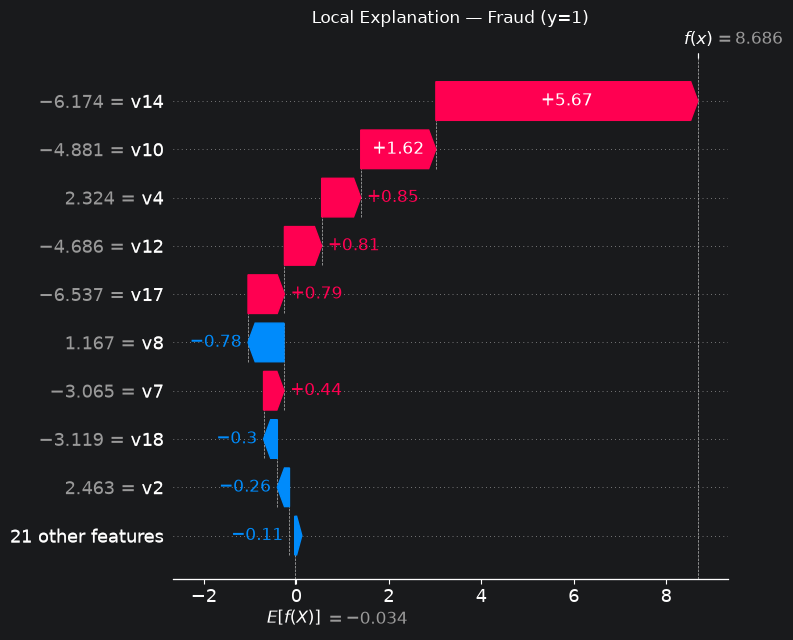

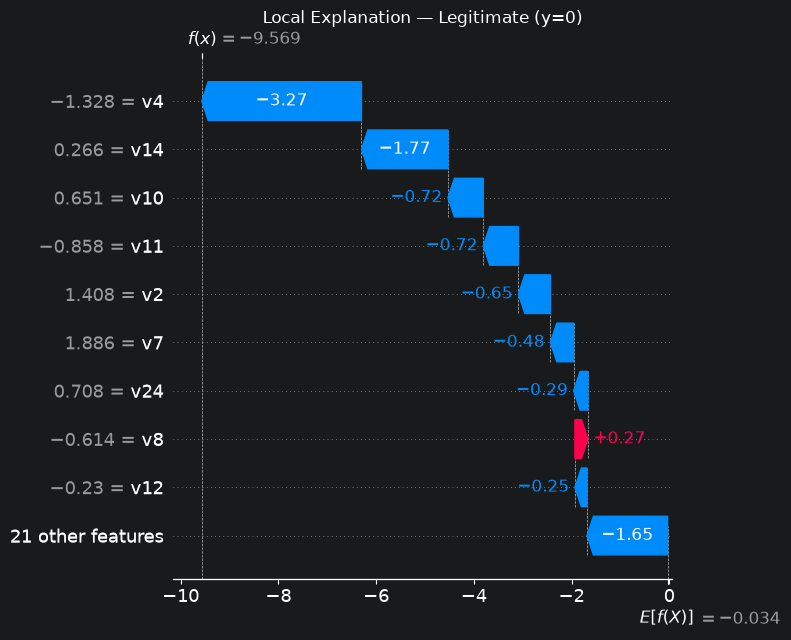

In [7]:
fraud_idx = numpy.where(test_y_np == 1)[0][0]
legit_idx = numpy.where(test_y_np == 0)[0][0]

for index, label in [
    (int(fraud_idx), "Fraud"),
    (int(legit_idx), "Legitimate"),
]:
    shap.plots.waterfall(
        shap.Explanation(
            values=shap_values[index],
            base_values=explainer.expected_value,
            data=test_x.iloc[index].to_numpy(),
            feature_names=feature_names,
        ),
        show=False,
    )
    pyplot.title(f"Local Explanation — {label} (y={test_y_np[index]})")
    pyplot.tight_layout()
    pyplot.show()